## Muhammad Imtanan Mujahid


## Internee ID : NFS-2607-0716

# EDA on "Titanic - Machine Learning from Disaster" Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:

df = pd.read_csv(r"C:\Users\Imtanan\Downloads\train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print(f"Rows: {df.shape[0]} , Columns: {df.shape[1]}")

Rows: 891 , Columns: 12


In [7]:
df.isnull().sum().sort_values()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Age            177
Cabin          687
dtype: int64

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

In [9]:
print("Categorical Columns: " , cat_cols)
print("Numerical Columns: " , num_cols)

Categorical Columns:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical Columns:  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


# Data Story

I am working with the "Titanic - Machine Learning from Disaster" dataset, which has 891 rows and 12 columns: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, and Embarked. Three columns have missing values: Embarked (2 missing), Age (177 missing), and Cabin (687 missing) — Cabin being missing for over 75% of passengers means it likely can't be reliably filled in with a guess. Out of the 12 columns, five are categorical (Name, Sex, Ticket, Cabin, Embarked) and seven are numerical (PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare), though Survived and Pclass are technically stored as numbers but really represent categories rather than true measurements.

# Data Visualization

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

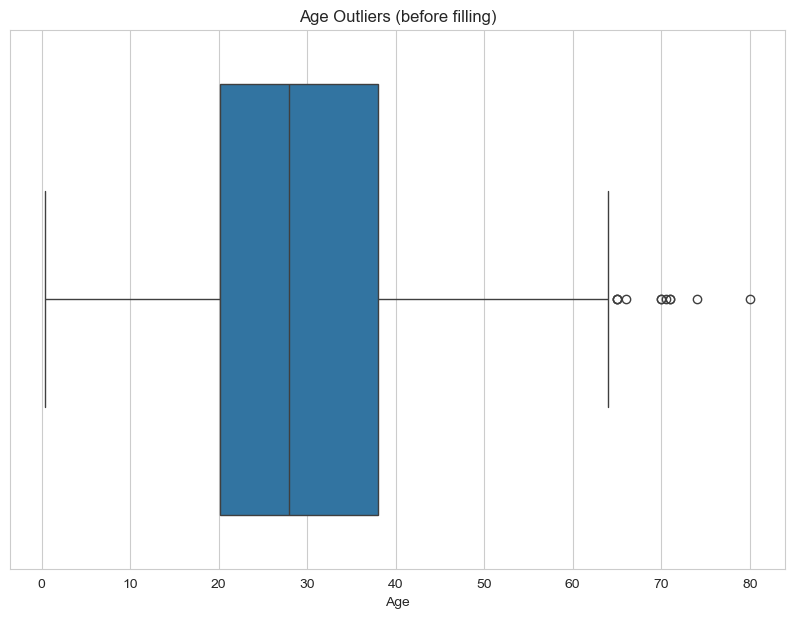

In [11]:
plt.figure(figsize=(10,7))
sns.boxplot(x=df['Age'])
plt.title('Age Outliers (before filling)')
plt.show()

In [12]:

print("Age skew: " , df['Age'].skew())
print("Age mean :" , df['Age'].mean())
print("Age median :" , df['Age'].median())






Age skew:  0.38910778230082704
Age mean : 29.69911764705882
Age median : 28.0


In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Before filling Age, I checked its boxplot and found several older passengers
standing out as outliers. The skew number (0.39) confirmed the data leans
toward higher ages. The average age (29.7) was higher than the middle age
(28.0), showing those few older passengers were pulling the average up.
So I filled missing Age values with the median, since it isn't affected by
those extreme ages.

In [14]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')



Embarked only had 2 missing values, so I filled them with the mode.
Cabin was missing for most passengers (about 77%), so instead of guessing,
I labeled the missing ones as 'Unknown'.

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

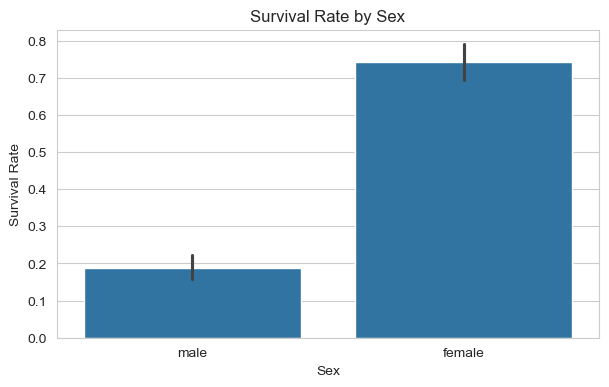

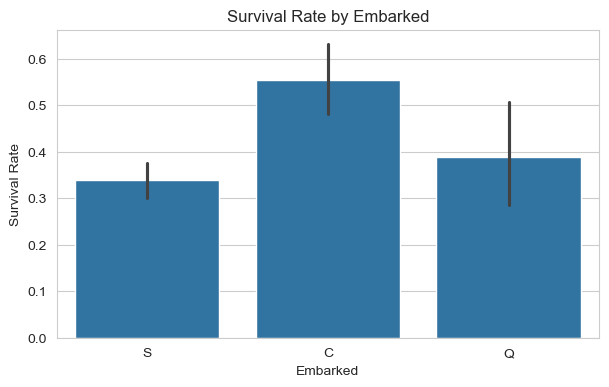

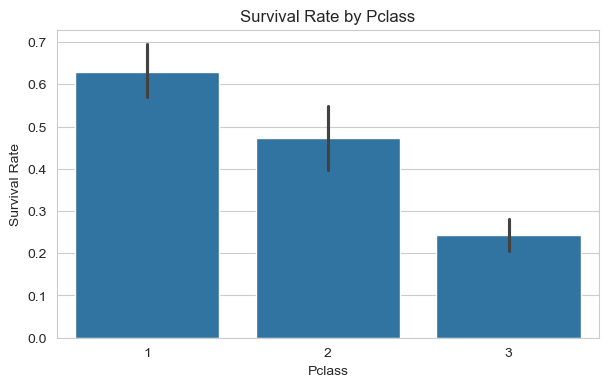

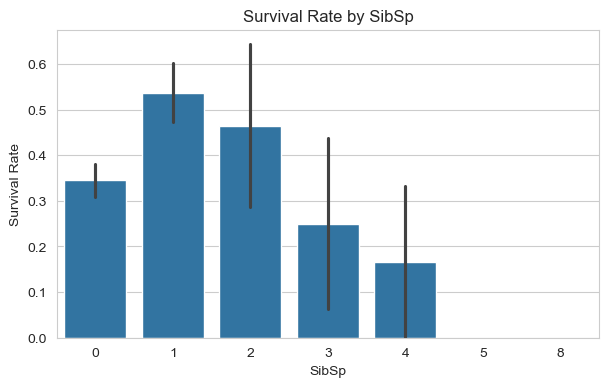

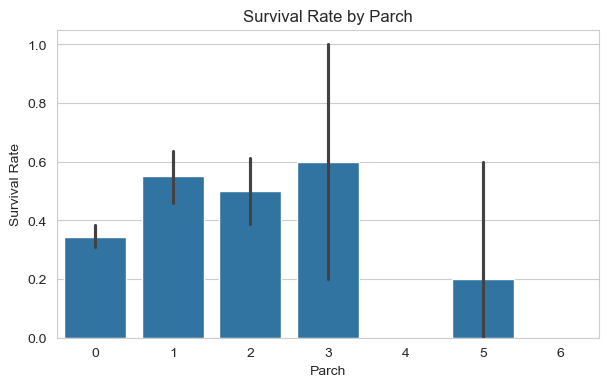

In [16]:
cate_cols = ['Sex','Embarked','Pclass']
discrete_cols = ['SibSp','Parch']
for col in cate_cols + discrete_cols:
    plt.figure(figsize=(7,4))
    sns.barplot(x=col,y='Survived',data=df)
    plt.title(f"Survival Rate by {col}")
    plt.ylabel("Survival Rate")
    plt.show()

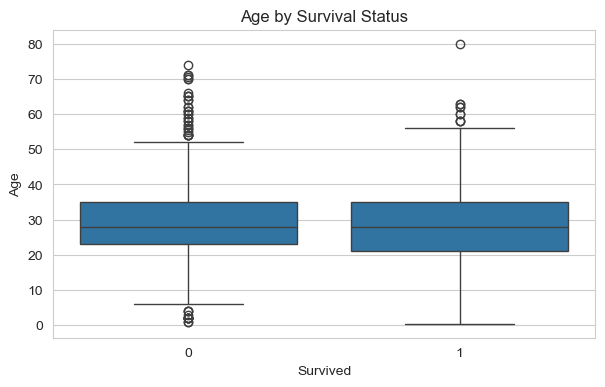

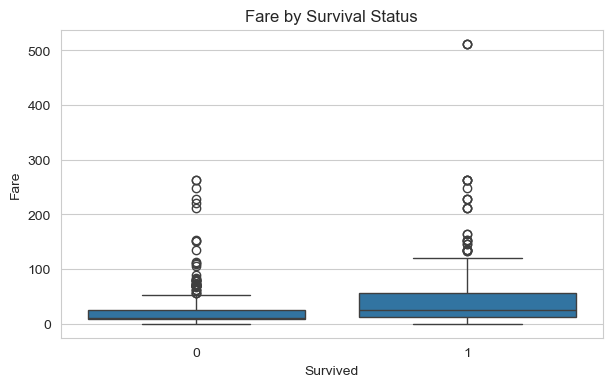

In [17]:
for col in ['Age' , 'Fare']:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='Survived' , y=col,data=df)
    plt.title(f'{col} by Survival Status')
    plt.show()

The Fare boxplot shows a clear difference between groups: survivors
typically paid higher fares than non-survivors, and their fares were more
spread out. Both groups show high-fare outliers, including one extreme
value near 512 among survivors. This supports the idea that wealth/class
played a role in survival.

The Age boxplot, by contrast, shows almost no difference between
survivors and non-survivors — both groups have a similar median age and
similar spread, with a few older outliers (60-80) present in both groups.
This suggests age alone was not a strong factor in survival.

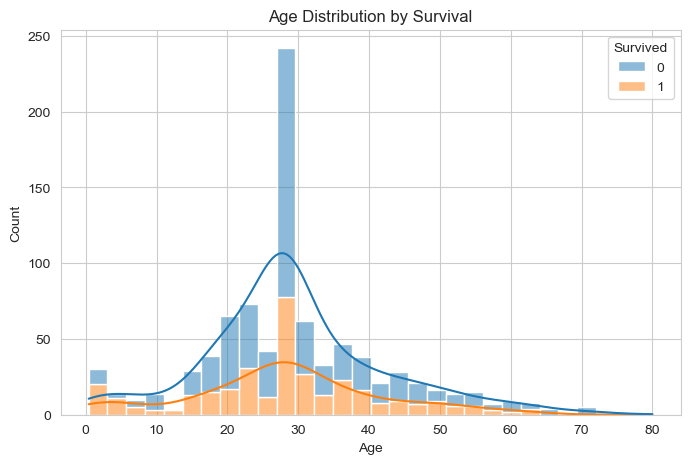

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, multiple='stack')
plt.title('Age Distribution by Survival')
plt.show()

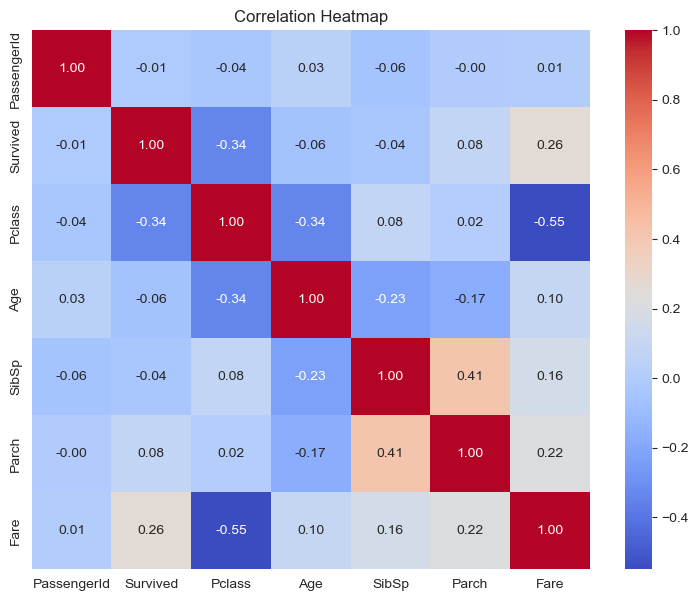

In [19]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Looking at all my charts, Sex stands out as the strongest factor — women survived at about 74%, compared to just 19% of men, backed by hundreds of passengers in each group.
Pclass and Fare come in second. The heatmap shows these are the only numeric columns with a real link to Survived (Pclass -0.34, Fare 0.26), and since they're strongly correlated with each other (-0.55), they're really both reflecting wealth/class. This matches the bar chart, where survival dropped from 63% in 1st class to 24% in 3rd class.
Age, SibSp, and Parch showed little to no reliable effect — Age looked nearly identical between survivors and non-survivors, and the family-size columns only had enough data to trust the smaller group sizes.
Overall, Sex was the strongest predictor of survival, with Pclass/Fare as the second most important factor.